In [1]:
import sys
!{sys.executable} -m pip install networkx matplotlib

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a sample graph
G = nx.Graph()
G.add_edges_from([
    ('A', 'B'), ('A', 'C'), ('A', 'D'),
    ('B', 'D'), ('B', 'E'),
    ('C', 'F'), ('C', 'G'),
    ('D', 'H'),
    ('E', 'I'),
    ('F', 'J'),
    ('G', 'K')
])

# Add node attributes (e.g., 'community' or 'type')
nodes_with_community1 = ['A', 'B', 'D', 'E', 'H', 'I']
nodes_with_community2 = ['C', 'F', 'G', 'J', 'K']

for node in G.nodes():
    if node in nodes_with_community1:
        G.nodes[node]['community'] = 'red'
    elif node in nodes_with_community2:
        G.nodes[node]['community'] = 'blue'
    else:
        G.nodes[node]['community'] = 'green'

# Add edge attributes (e.g., 'weight' or 'strength')
G.edges[('A', 'B')]['weight'] = 5
G.edges[('A', 'C')]['weight'] = 1
G.edges[('B', 'D')]['weight'] = 3
G.edges[('C', 'F')]['weight'] = 2
G.edges[('G', 'K')]['weight'] = 4

# Set default edge weights if not assigned
for u, v, d in G.edges(data=True):
    if 'weight' not in d:
        d['weight'] = 1

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print("Node attributes (sample):")
for i, node in enumerate(G.nodes()):
    if i < 3:
        print(f"  {node}: {G.nodes[node]}")
print("Edge attributes (sample):")
for i, edge in enumerate(G.edges(data=True)):
    if i < 3:
        print(f"  {edge}")

Number of nodes: 11
Number of edges: 11
Node attributes (sample):
  A: {'community': 'red'}
  B: {'community': 'red'}
  C: {'community': 'blue'}
Edge attributes (sample):
  ('A', 'B', {'weight': 5})
  ('A', 'C', {'weight': 1})
  ('A', 'D', {'weight': 1})


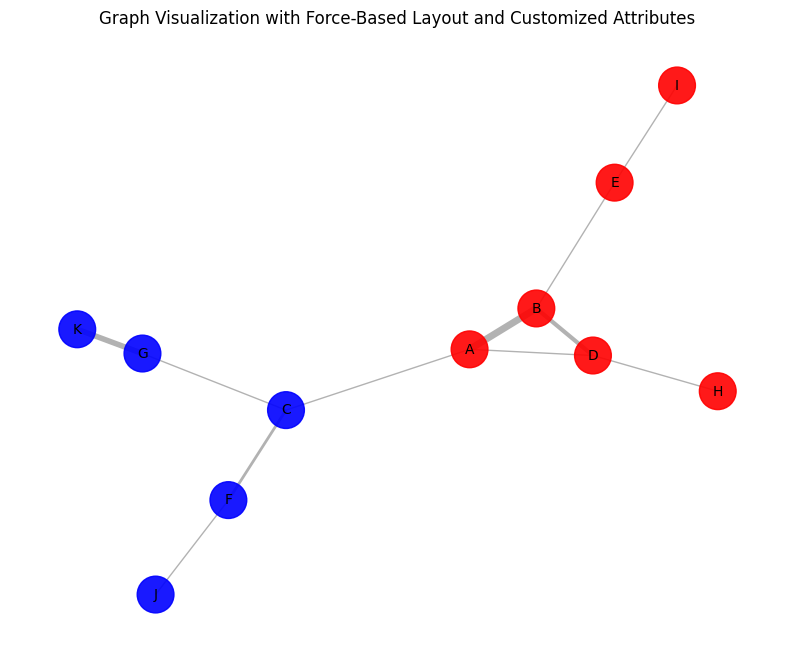

In [3]:
# Define node colors based on 'community' attribute
node_colors = [G.nodes[node]['community'] for node in G.nodes()]

# Define edge widths based on 'weight' attribute
edge_widths = [G.edges[u, v]['weight'] for u, v in G.edges()]

plt.figure(figsize=(10, 8))

# Use spring_layout for a force-directed layout
pos = nx.spring_layout(G, k=0.5, iterations=50) # k regulates distance between nodes

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700, alpha=0.9)

# Draw edges with varying widths
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6, edge_color='gray')

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')

plt.title('Graph Visualization with Force-Based Layout and Customized Attributes')
plt.axis('off') # Hide axes
plt.show()

Node Centrality Measures:
  Node A:
    Degree: 0.300
    Betweenness: 0.556
    Eigenvector: 0.517
  Node B:
    Degree: 0.300
    Betweenness: 0.356
    Eigenvector: 0.489
  Node C:
    Degree: 0.300
    Betweenness: 0.622
    Eigenvector: 0.332
  Node D:
    Degree: 0.300
    Betweenness: 0.200
    Eigenvector: 0.477
  Node E:
    Degree: 0.200
    Betweenness: 0.200
    Eigenvector: 0.232
  Node F:
    Degree: 0.200
    Betweenness: 0.200
    Eigenvector: 0.157
  Node G:
    Degree: 0.200
    Betweenness: 0.200
    Eigenvector: 0.157
  Node H:
    Degree: 0.100
    Betweenness: 0.000
    Eigenvector: 0.190
  Node I:
    Degree: 0.100
    Betweenness: 0.000
    Eigenvector: 0.092
  Node J:
    Degree: 0.100
    Betweenness: 0.000
    Eigenvector: 0.063
  Node K:
    Degree: 0.100
    Betweenness: 0.000
    Eigenvector: 0.063


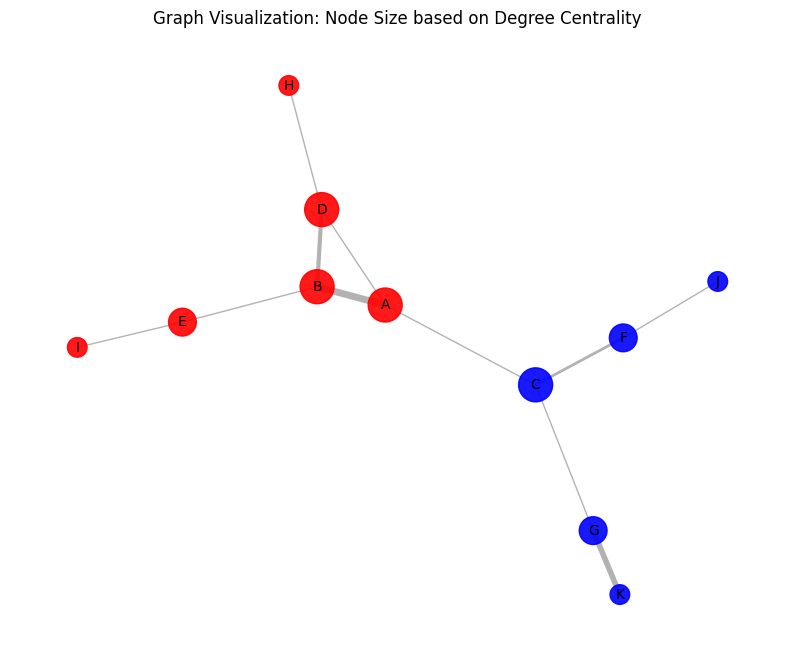

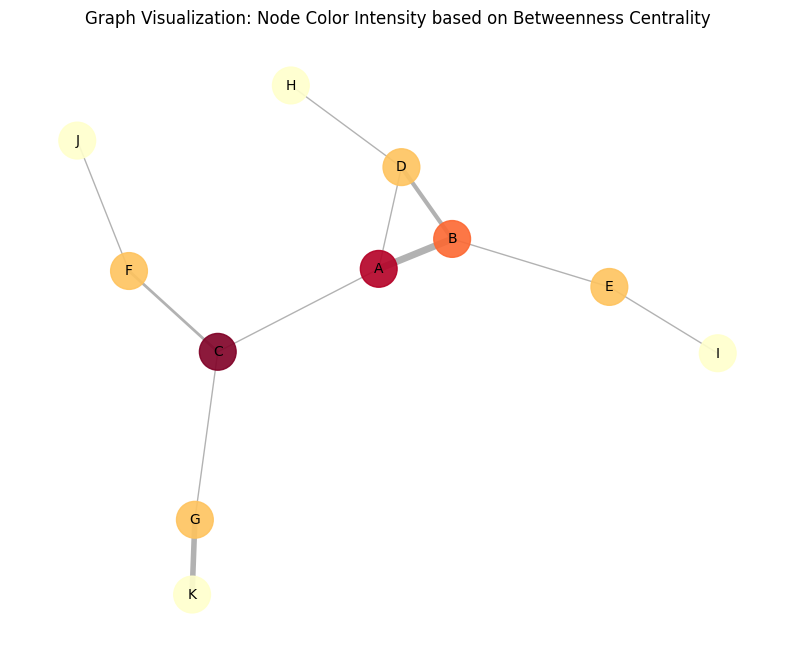

In [4]:
# Calculate centrality measures
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)

# Print centrality measures for each node
print("Node Centrality Measures:")
for node in G.nodes():
    print(f"  Node {node}:\n    Degree: {degree_centrality[node]:.3f}\n    Betweenness: {betweenness_centrality[node]:.3f}\n    Eigenvector: {eigenvector_centrality[node]:.3f}")

# Visualize degree centrality by varying node size
node_size_degree = [v * 2000 for v in degree_centrality.values()]

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.5, iterations=50)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_size_degree, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')
plt.title('Graph Visualization: Node Size based on Degree Centrality')
plt.axis('off')
plt.show()

# Visualize betweenness centrality by varying node color intensity (example: darker for higher centrality)
max_betweenness = max(betweenness_centrality.values())
node_colors_betweenness = [plt.cm.YlOrRd(v / max_betweenness) for v in betweenness_centrality.values()]

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.5, iterations=50)
nx.draw_networkx_nodes(G, pos, node_color=node_colors_betweenness, node_size=700, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')
plt.title('Graph Visualization: Node Color Intensity based on Betweenness Centrality')
plt.axis('off')
plt.show()